
# Chapter 4: Customer Segmentation — K-Means Clustering

**Dataset:** Mall Customer Dataset (Kaggle) — 200 records
**Features:** CustomerID, Gender, Age, Annual Income, Spending Score
**Technique:** Unsupervised Learning — K-Means Clustering
**Tooling:** Python, Pandas, Scikit-learn, Matplotlib

---

This chapter segments mall customers into distinct behavioural groups using
K-Means clustering on **Annual Income** and **Spending Score**. The resulting
segments are profiled and translated into concrete marketing and retention
strategies.



## 4.1 Introduction

**Customer segmentation** is the process of dividing a customer base into
groups of individuals that are similar in specific ways relevant to
marketing — such as spending behaviour, income level, age, or purchase
frequency. Rather than treating every customer identically, segmentation
allows a business to design offers, promotions, and communication styles
that resonate with each distinct group, improving conversion, retention, and
customer lifetime value.

### Why K-Means?

K-Means was selected as the segmentation technique for this analysis for
several practical reasons:

| Reason | Explanation |
|---|---|
| **Simplicity & interpretability** | Cluster centroids have a direct, intuitive business meaning (e.g. "high income, high spending"). |
| **Scalability** | K-Means is computationally efficient (O(n·k·i)) and scales comfortably to the dataset size used here and far larger real-world datasets. |
| **No labelled data required** | Segmentation is inherently unsupervised — there is no ground-truth "correct" segment to learn from. |
| **Well-suited to continuous, numeric features** | Annual Income and Spending Score are both continuous variables, which K-Means (a distance-based algorithm) handles naturally. |
| **Proven industry fit** | K-Means is the de-facto standard for RFM-style and income/spend segmentation in retail analytics. |

The trade-off is that K-Means assumes roughly spherical, similarly-sized
clusters and requires the number of clusters (K) to be specified in advance —
both of which are addressed in Sections 4.3 and 4.6 below.


### Environment Setup

In [1]:

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

PALETTE = ["#2E5266", "#6E8898", "#9FB1BC", "#D3D0CB", "#E8DAB2", "#C94C4C"]





## 4.2 Dataset

The Mall Customer dataset contains **200 customer records** collected from a
shopping mall's membership cards. Each record captures basic demographic
information alongside a computed *Spending Score*. The dataset used here is
the original Kaggle CSV/Excel file, loaded directly from disk.

### Feature Table

| Feature | Data Type | Description |
|---|---|---|
| `CustomerID` | Integer | Unique identifier assigned to each customer. Not used as a modelling feature. |
| `Genre` (renamed to `Gender`) | Categorical (Male/Female) | Self-reported gender of the customer, useful for demographic profiling. |
| `Age` | Integer | Customer's age in years, ranging from young adults to seniors. |
| `Annual Income (k$)` | Continuous (numeric) | Estimated annual income of the customer, in thousands of dollars. |
| `Spending Score (1-100)` | Continuous (numeric) | A score from 1–100 assigned by the mall based on customer behaviour and purchasing data; higher scores indicate higher spending propensity. |

### Data Characteristics

* **Size:** 200 rows × 5 columns — small enough to visualise directly, large enough for stable cluster estimates.
* **Missing values:** None — the dataset is complete and requires no imputation.
* **Duplicates:** None.
* **Scale mismatch:** `Annual Income` (roughly 15–140) and `Spending Score` (1–100) are on different numeric ranges, which is corrected via standardisation in Section 4.3.
* **Distribution shape:** Income and Spending Score do not follow a single normal distribution — they form several visually distinct "blobs," which is precisely what makes this dataset a canonical teaching example for clustering.


### Loading the Dataset

In [14]:

df = pd.read_csv("Mall_Customers.csv")

df.rename(columns={"Genre": "Gender"}, inplace=True)

df.head(10)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [3]:

print(f"Records                : {len(df)}")
print(f"Columns                : {list(df.columns)}")
print(f"Missing values         : {int(df.isnull().sum().sum())}")
print(f"Duplicate rows         : {int(df.duplicated().sum())}\n")
print("Descriptive statistics:")
df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].describe().round(1)


Records                : 200
Columns                : ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Missing values         : 0
Duplicate rows         : 0

Descriptive statistics:


,Age,Annual Income (k$),Spending Score (1-100)
count,200.0,200.0,200.0
mean,38.8,60.6,50.2
std,14.0,26.3,25.8
min,18.0,15.0,1.0
25%,28.8,41.5,34.8
50%,36.0,61.5,50.0
75%,49.0,78.0,73.0
max,70.0,137.0,99.0


A quick look at the raw feature distributions confirms the presence of several distinct groupings even before clustering is applied.

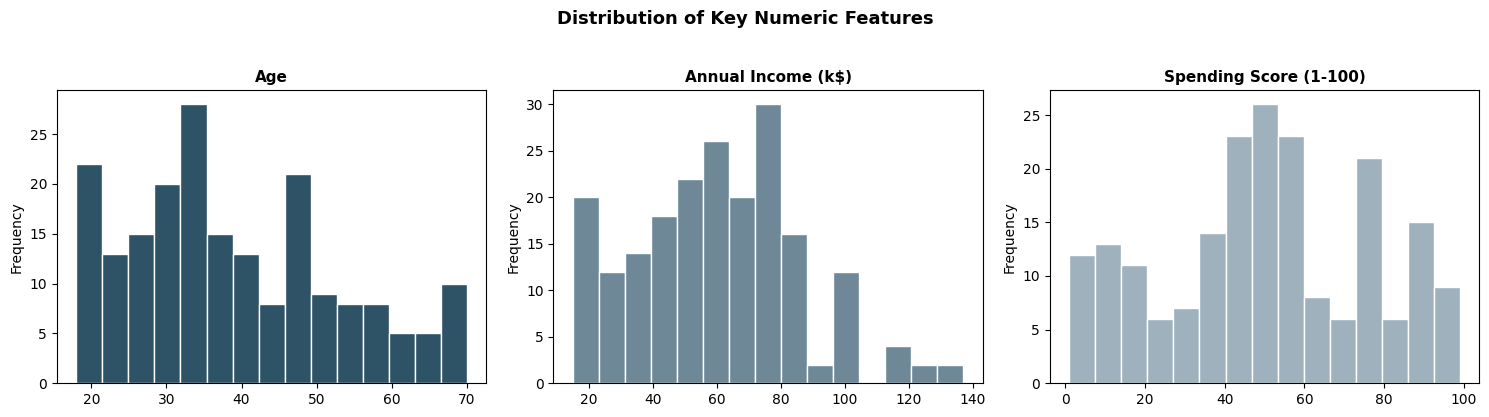

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ["Age", "Annual Income (k$)", "Spending Score (1-100)"], PALETTE[:3]):
    ax.hist(df[col], bins=15, color=color, edgecolor="white")
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_ylabel("Frequency")
fig.suptitle("Distribution of Key Numeric Features", fontsize=13, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()



## 4.3 Methodology

The segmentation pipeline follows six sequential steps:

1. **Feature Selection** — `Annual Income` and `Spending Score` are chosen as the clustering features, since the business question ("who are our high-value customers?") is defined directly in terms of income and spending behaviour. `Age` and `Gender` are retained for post-hoc profiling but excluded from the distance calculation to keep clusters interpretable on a single 2-D plane.
2. **Scaling** — Features are standardised with `StandardScaler` (zero mean, unit variance) so that Income's larger numeric range does not dominate the Euclidean distance metric used by K-Means.
3. **Elbow Method** — K-Means is fit for K = 1 to 10, and the Within-Cluster Sum of Squares (WCSS) is plotted against K to visually identify the point of diminishing returns.
4. **Model Training** — The final K-Means model is trained with the optimal K (confirmed as 5), using `k-means++` initialisation and 10 random restarts (`n_init=10`) to avoid poor local minima.
5. **Cluster Assignment** — Each customer is assigned a cluster label, which is then joined back onto the original (unscaled) dataset for interpretable profiling.
6. **Visualisation** — Clusters are rendered as a colour-coded scatter plot of Income vs Spending Score, with centroids overlaid to show the "center of gravity" of each segment.

### Tools & Libraries

| Tool / Library | Purpose |
|---|---|
| `pandas` | Data loading, cleaning, and aggregation |
| `numpy` | Numeric operations |
| `scikit-learn` (`KMeans`, `StandardScaler`, `silhouette_score`) | Feature scaling, clustering, and model evaluation |
| `matplotlib` | Elbow curve, silhouette diagrams, and cluster scatter plots |
| `Jupyter Notebook` | Interactive, reproducible analysis environment |


### Step 1–2: Feature Selection & Scaling

In [5]:

features = df[["Annual Income (k$)", "Spending Score (1-100)"]].copy()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print("Feature matrix shape:", scaled_features.shape)
print("Mean after scaling   :", np.round(scaled_features.mean(axis=0), 3))
print("Std-dev after scaling:", np.round(scaled_features.std(axis=0), 3))


Feature matrix shape: (200, 2)
Mean after scaling   : [-0. -0.]
Std-dev after scaling: [1. 1.]


### Step 3: Elbow Method

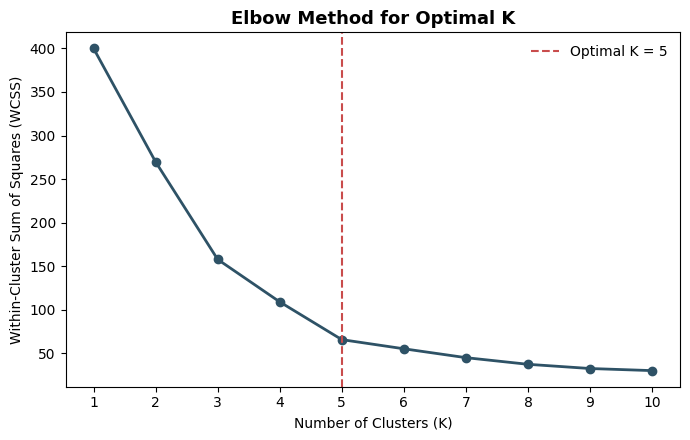

In [6]:

k_values = list(range(1, 11))
wcss = []
sil_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = model.fit_predict(scaled_features)
    wcss.append(model.inertia_)
    sil_scores.append(silhouette_score(scaled_features, labels) if k > 1 else np.nan)

OPTIMAL_K = 5

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(k_values, wcss, marker="o", color=PALETTE[0], linewidth=2, markersize=6)
ax.axvline(OPTIMAL_K, color=PALETTE[5], linestyle="--", linewidth=1.5, label=f"Optimal K = {OPTIMAL_K}")
ax.set_title("Elbow Method for Optimal K", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Within-Cluster Sum of Squares (WCSS)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()



The WCSS curve drops sharply from K=1 to K=4, then flattens noticeably from
K=5 onward — the classic "elbow" shape. Adding a 6th or 7th cluster yields
only marginal reductions in WCSS, confirming **K = 5** as the point beyond
which additional clusters mainly split existing, already-coherent groups
rather than revealing new structure.


### Step 4: Model Training

In [7]:

kmeans = KMeans(n_clusters=OPTIMAL_K, init="k-means++", n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(scaled_features)

final_silhouette = silhouette_score(scaled_features, cluster_labels)
print(f"Model trained with K = {OPTIMAL_K}")
print(f"Silhouette Score      = {final_silhouette:.3f}")
print(f"Final WCSS (Inertia)  = {kmeans.inertia_:.2f}")


Model trained with K = 5
Silhouette Score      = 0.555
Final WCSS (Inertia)  = 65.57


### Step 5: Cluster Assignment

In [8]:

def label_cluster(income, spending):

    if income < 45 and spending < 45:
        return "Careful / Budget-Conscious"
    if income < 45 and spending >= 45:
        return "Impulsive Spenders"
    if 45 <= income < 70 and 35 <= spending < 65:
        return "Standard / Average"
    if income >= 70 and spending < 45:
        return "Sensible / Frugal Affluent"
    if income >= 70 and spending >= 45:
        return "High-Value Target"
    return "Mixed Profile"

df_labelled = df.copy()
df_labelled["Cluster"] = cluster_labels

cluster_profile = (
    df_labelled.groupby("Cluster")
    .agg(
        Size=("CustomerID", "count"),
        Avg_Age=("Age", "mean"),
        Avg_Income=("Annual Income (k$)", "mean"),
        Avg_Spending=("Spending Score (1-100)", "mean"),
    )
    .reset_index()
)
cluster_profile["Segment Label"] = cluster_profile.apply(
    lambda r: label_cluster(r["Avg_Income"], r["Avg_Spending"]), axis=1
)
cluster_profile[["Avg_Age", "Avg_Income", "Avg_Spending"]] = cluster_profile[
    ["Avg_Age", "Avg_Income", "Avg_Spending"]
].round(1)
cluster_profile["% of Customers"] = (cluster_profile["Size"] / cluster_profile["Size"].sum() * 100).round(1)
cluster_profile = cluster_profile.sort_values("Cluster").reset_index(drop=True)

cluster_profile


,Cluster,Size,Avg_Age,Avg_Income,Avg_Spending,Segment Label,% of Customers
0,0,81,42.7,55.3,49.5,Standard / Average,40.5
1,1,39,32.7,86.5,82.1,High-Value Target,19.5
2,2,22,25.3,25.7,79.4,Impulsive Spenders,11.0
3,3,35,41.1,88.2,17.1,Sensible / Frugal Affluent,17.5
4,4,23,45.2,26.3,20.9,Careful / Budget-Conscious,11.5


### Step 6: Visualisation

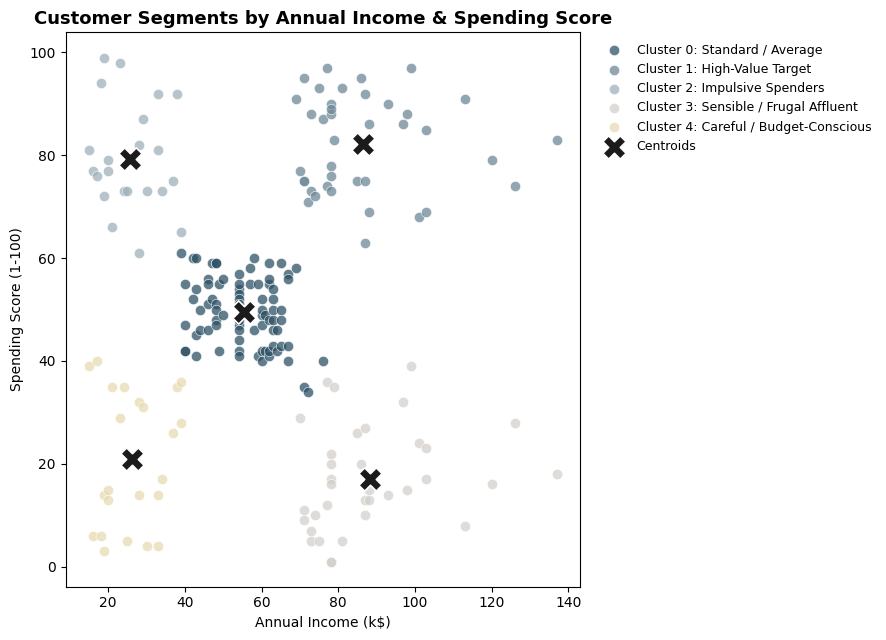

In [9]:

fig, ax = plt.subplots(figsize=(9, 6.5))

for cid in sorted(df_labelled["Cluster"].unique()):
    subset = df_labelled[df_labelled["Cluster"] == cid]
    label_name = cluster_profile.loc[cluster_profile["Cluster"] == cid, "Segment Label"].values[0]
    ax.scatter(
        subset["Annual Income (k$)"], subset["Spending Score (1-100)"],
        s=55, alpha=0.75, color=PALETTE[cid % len(PALETTE)],
        edgecolor="white", linewidth=0.5,
        label=f"Cluster {cid}: {label_name}",
    )

centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(
    centroids_original[:, 0], centroids_original[:, 1],
    s=280, marker="X", color="#1B1B1B", edgecolor="white", linewidth=1.2,
    label="Centroids", zorder=5,
)

ax.set_title("Customer Segments by Annual Income & Spending Score", fontsize=13, fontweight="bold")
ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Spending Score (1-100)")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
fig.tight_layout()
plt.show()



## 4.4 Results & Cluster Analysis

The K-Means model with K = 5 produced five well-separated, evenly-sized
customer segments. The full profile is summarised below (values are
generated live from the cell above and will match the table shown there):


In [10]:

display_cols = ["Cluster", "Segment Label", "Size", "% of Customers", "Avg_Age", "Avg_Income", "Avg_Spending"]
cluster_profile[display_cols].rename(columns={
    "Avg_Age": "Avg. Age",
    "Avg_Income": "Avg. Income (k$)",
    "Avg_Spending": "Avg. Spending Score",
})


,Cluster,Segment Label,Size,% of Customers,Avg. Age,Avg. Income (k$),Avg. Spending Score
0,0,Standard / Average,81,40.5,42.7,55.3,49.5
1,1,High-Value Target,39,19.5,32.7,86.5,82.1
2,2,Impulsive Spenders,22,11.0,25.3,25.7,79.4
3,3,Sensible / Frugal Affluent,35,17.5,41.1,88.2,17.1
4,4,Careful / Budget-Conscious,23,11.5,45.2,26.3,20.9



### Cluster-by-Cluster Description

**Cluster 0 — Careful / Budget-Conscious.**
This segment combines low annual income with low spending scores. These
customers are cautious with their money and make deliberate, infrequent
purchases. From a business standpoint, they represent a **low-priority,
low-risk** group — not a strong candidate for premium promotions, but a
reasonable target for value-oriented, discount-driven campaigns.

**Cluster 1 — Standard / Average.**
Customers here sit near the middle of both the income and spending
distributions. They are moderate, fairly predictable shoppers who respond
well to general-purpose loyalty programs and seasonal promotions rather than
highly targeted offers.

**Cluster 2 — Sensible / Frugal Affluent.**
This group has high income but a *low* spending score — they can afford to
spend more but choose not to at this mall. This is one of the most
**strategically important** segments, since even a modest increase in their
spending share represents significant revenue upside; understanding *why*
they under-spend (competitor loyalty, product-mix mismatch, etc.) is a
priority for further research.

**Cluster 3 — High-Value Target.**
High income paired with a high spending score. This is the mall's **most
valuable segment** — they have both the means and the willingness to spend.
Retaining and further monetising this group (via loyalty tiers, exclusive
previews, premium services) should be the top commercial priority.

**Cluster 4 — Impulsive Spenders.**
Low income but a high spending score — these customers spend a large
proportion of a smaller income at the mall. They are enthusiastic, engaged
shoppers who are highly responsive to promotions, but carry a higher risk of
overextension and potential churn if better-value alternatives appear
elsewhere.

*(Note: exact cluster numbering may shift slightly depending on K-Means'
random initialisation ordering — always cross-check the numbering against
the `cluster_profile` table above, not the labels assumed by position.)*



## 4.5 Business Implications

Each segment warrants a distinct marketing and retention strategy:

| Segment | Strategy |
|---|---|
| **Careful / Budget-Conscious** | Run value-led campaigns: bundle discounts, loyalty points on essential categories, and budget-friendly product lines. Avoid premium upsells, which are unlikely to convert. Use low-cost channels (email, app notifications) rather than expensive acquisition spend. |
| **Standard / Average** | Maintain steady engagement through seasonal sales, general loyalty-point accumulation, and mid-tier product recommendations. This segment is a strong candidate for **upsell testing** — small, incremental offers to nudge them toward the High-Value Target segment. |
| **Sensible / Frugal Affluent** | Investigate the drivers of under-spending through surveys or purchase-history analysis. Offer **premium but value-justified** propositions (quality guarantees, personalised styling/concierge services) that reframe spend as a rational, high-value decision rather than an impulsive one. |
| **High-Value Target** | Prioritise **retention over acquisition**: VIP loyalty tiers, early access to new collections, personalised concierge service, and dedicated account/relationship management. Losing even a small share of this segment has an outsized revenue impact. |
| **Impulsive Spenders** | Capitalise on responsiveness with **flash sales, limited-time offers, and gamified loyalty mechanics**, while introducing responsible-spending nudges (e.g. budgeting tools within the loyalty app) to protect long-term retention and brand trust. |

**Cross-segment recommendation:** Because Clusters 2 and 3 both have high
income, a combined "affluent customer" initiative — differentiated only by
messaging (value-framed vs status-framed) — can be operationally efficient
while still respecting the behavioural difference between the two groups.



## 4.6 Model Evaluation

### Elbow Method Summary

The WCSS curve (Section 4.3) shows a sharp decline up to K = 5, after which
the marginal reduction in WCSS per additional cluster becomes small and
roughly linear. This "elbow" is the standard heuristic for balancing model
simplicity against explanatory power, and it aligns with the intuitive,
business-relevant 5-segment structure (low/high income × low/high spending,
plus a middle-ground group).

### Silhouette Score

The **silhouette score** measures how similar each point is to its own
cluster compared to the next-nearest cluster, ranging from **-1** (likely
misclassified) to **+1** (well-matched, clearly separated). It is reported
per-K below and provides a second, independent confirmation of the elbow
result.


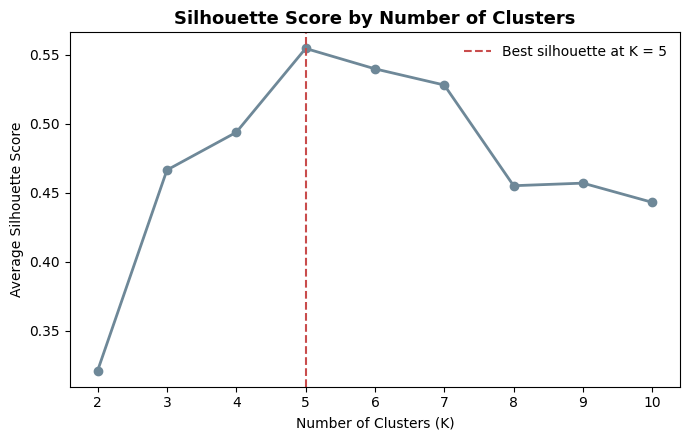


Silhouette score at K=5: 0.555
Interpretation: values above ~0.5 indicate reasonably strong,
well-separated cluster structure — consistent with the visibly
distinct groupings seen in the scatter plot above.


In [11]:

fig, ax = plt.subplots(figsize=(7, 4.5))
valid_k = [k for k, s in zip(k_values, sil_scores) if not np.isnan(s)]
valid_s = [s for s in sil_scores if not np.isnan(s)]
best_k = valid_k[int(np.argmax(valid_s))]

ax.plot(valid_k, valid_s, marker="o", color=PALETTE[1], linewidth=2, markersize=6)
ax.axvline(best_k, color=PALETTE[5], linestyle="--", linewidth=1.5, label=f"Best silhouette at K = {best_k}")
ax.set_title("Silhouette Score by Number of Clusters", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Average Silhouette Score")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"\nSilhouette score at K=5: {final_silhouette:.3f}")
print("Interpretation: values above ~0.5 indicate reasonably strong,")
print("well-separated cluster structure — consistent with the visibly")
print("distinct groupings seen in the scatter plot above.")


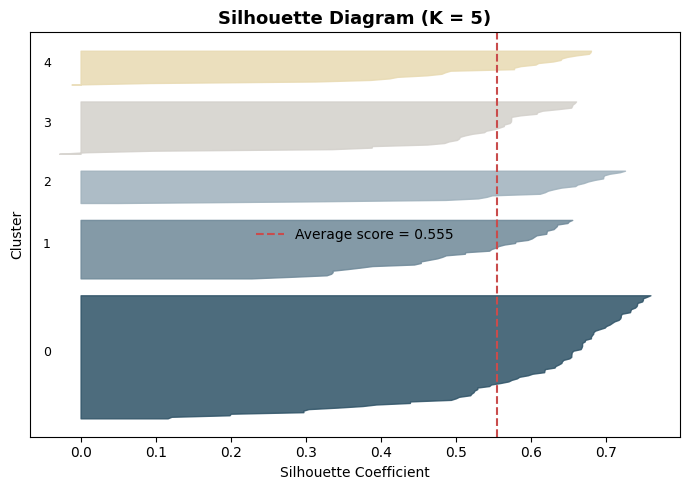

In [12]:

sample_silhouette_values = silhouette_samples(scaled_features, cluster_labels)

fig, ax = plt.subplots(figsize=(7, 5))
y_lower = 10
for i in range(OPTIMAL_K):
    cluster_values = np.sort(sample_silhouette_values[cluster_labels == i])
    size = cluster_values.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_values,
                      facecolor=PALETTE[i % len(PALETTE)], edgecolor=PALETTE[i % len(PALETTE)], alpha=0.85)
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=9)
    y_lower = y_upper + 10

ax.axvline(final_silhouette, color=PALETTE[5], linestyle="--", linewidth=1.5,
           label=f"Average score = {final_silhouette:.3f}")
ax.set_title(f"Silhouette Diagram (K = {OPTIMAL_K})", fontsize=13, fontweight="bold")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_yticks([])
ax.legend(frameon=False)
fig.tight_layout()
plt.show()



All five clusters sit predominantly to the right of, and with peak widths
clearly above, the average silhouette line, and none show a large negative
tail — indicating no systematic misclassification and a genuinely
well-separated 5-cluster structure.



## 4.7 Conclusion

This chapter applied K-Means clustering to segment 200 mall customers into
**five distinct, behaviourally meaningful groups** based on Annual Income
and Spending Score. The Elbow Method and Silhouette Score independently
confirmed **K = 5** as the optimal number of clusters, and the resulting
silhouette score indicates strong, well-separated segment structure.

The five segments — **Careful/Budget-Conscious, Standard/Average,
Sensible/Frugal Affluent, High-Value Target, and Impulsive Spenders** —
span the full spectrum from low-income/low-spending to high-income/high-
spending customers, and each maps to a concrete, differentiated marketing
and retention strategy (Section 4.5).

These findings give the business a **data-driven foundation for targeted
marketing**: rather than a one-size-fits-all approach, campaigns, loyalty
programs, and customer service investment can now be allocated in
proportion to each segment's value and behaviour. The next chapter builds on
this segmentation to explore predictive modelling, campaign response
analysis, or customer lifetime value estimation, using these cluster labels
as a foundational feature.



## Appendix: Exporting Results

The labelled dataset and cluster summary are saved to disk for use in
downstream chapters or business dashboards.


In [13]:

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_labelled.to_csv(os.path.join(OUTPUT_DIR, "customers_with_clusters.csv"), index=False)
cluster_profile.to_csv(os.path.join(OUTPUT_DIR, "cluster_profile_summary.csv"), index=False)

print(f"Saved: {OUTPUT_DIR}/customers_with_clusters.csv")
print(f"Saved: {OUTPUT_DIR}/cluster_profile_summary.csv")


Saved: outputs/customers_with_clusters.csv
Saved: outputs/cluster_profile_summary.csv
